In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

In [2]:
FILENAME = "scope_4.csv"

DATA_DIR = "data/scope_csv"

data = np.loadtxt(f"{DATA_DIR}/{FILENAME}", delimiter=",", skiprows=2)

time = data[:, 0]
ch_agg = data[:, 1].astype(np.uint8)

In [3]:
num_samples = len(time)
print(f"Number of samples: {num_samples}")
acquisition_time = time[-1] - time[0]
print(f"Acquisition time: {acquisition_time} seconds")
acquisition_frequency = num_samples / acquisition_time
print(f"Acquisition frequency: {acquisition_frequency} Hz")

Number of samples: 63996
Acquisition time: 0.199984375 seconds
Acquisition frequency: 320005.00039065554 Hz


In [4]:
# ch_agg is a byte representing digital channels 0-7
ch_0 = np.right_shift(ch_agg, 0) & 1
ch_1 = np.right_shift(ch_agg, 1) & 1
ch_2 = np.right_shift(ch_agg, 2) & 1
ch_3 = np.right_shift(ch_agg, 3) & 1
ch_4 = np.right_shift(ch_agg, 4) & 1
# ch_5 = np.right_shift(ch_agg, 5) & 1
# ch_6 = np.right_shift(ch_agg, 6) & 1
# ch_7 = np.right_shift(ch_agg, 7) & 1

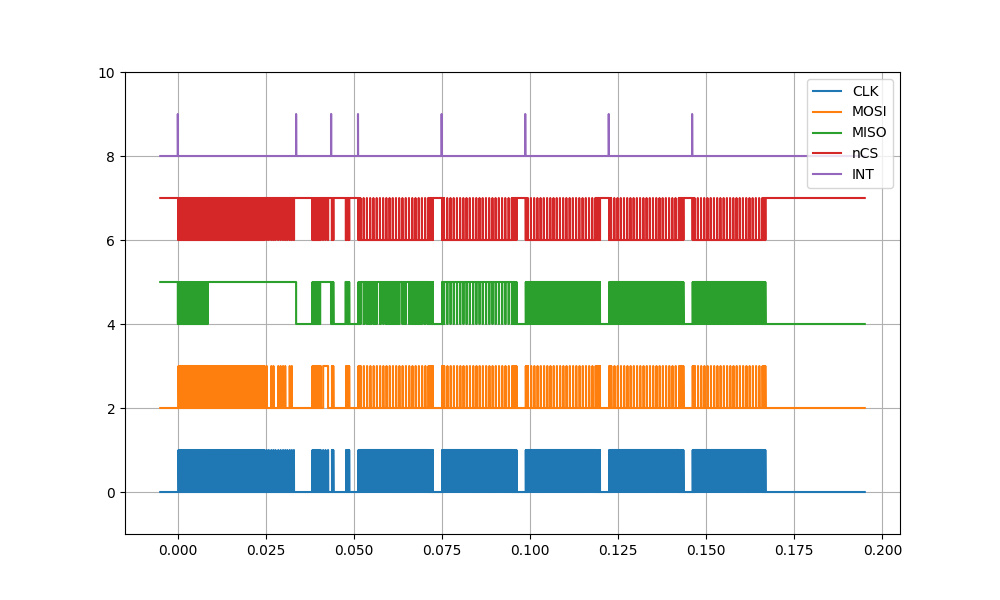

In [5]:
plt.figure(figsize=(10, 6))
plt.step(time, ch_0, where='post', label='CLK')
plt.step(time, ch_1 + 2, where='post', label='MOSI')
plt.step(time, ch_2 + 4, where='post', label='MISO')
plt.step(time, ch_3 + 6, where='post', label='nCS')
plt.step(time, ch_4 + 8, where='post', label='INT')
# plt.step(time, ch_5 + 10, where='post', label='Channel 5')
# plt.step(time, ch_6 + 12, where='post', label='Channel 6')
# plt.step(time, ch_7 + 14, where='post', label='Channel 7')
plt.xlim()
plt.ylim(-1, 10)
plt.legend(loc='upper right')
plt.grid()
plt.show()